This dashboard explores how dining context influences customer tipping behavior and overall restaurant revenue. While tip amounts scale linearly with the total bill across all shifts, an analysis of party size reveals that smaller tables actually leave higher tip percentages than larger groups. Ultimately, dinner service on weekends drives both the highest average spending and the widest variance in gratuity, pinpointing Friday and Saturday nights as the most lucrative shifts.

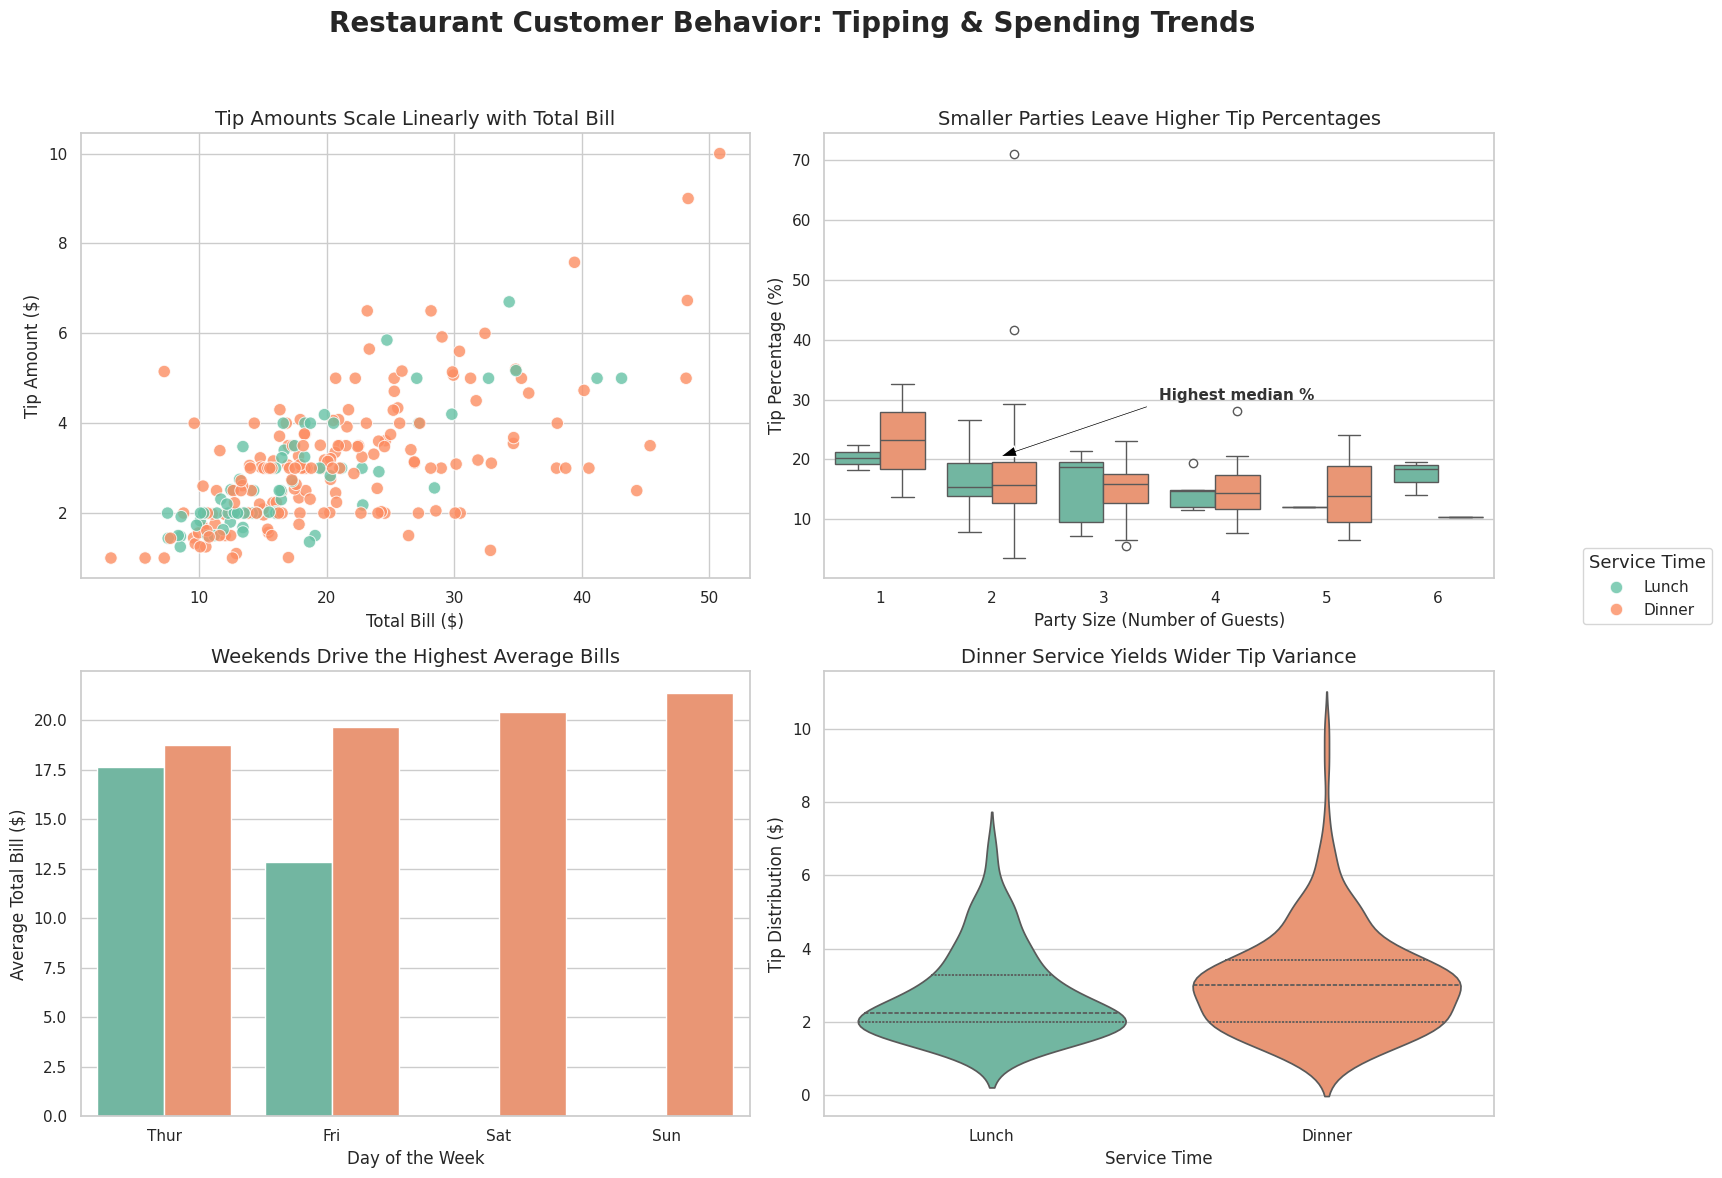

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('tips')
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100

sns.set_theme(style="whitegrid")
custom_palette = "Set2"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Restaurant Customer Behavior: Tipping & Spending Trends', 
             fontsize=20, weight='bold', y=0.98)

# Top-Left
sns.scatterplot(ax=axes[0, 0], data=df, x='total_bill', y='tip', 
                hue='time', palette=custom_palette, alpha=0.8, s=80)
axes[0, 0].set_title('Tip Amounts Scale Linearly with Total Bill', fontsize=14)
axes[0, 0].set_xlabel('Total Bill ($)', fontsize=12)
axes[0, 0].set_ylabel('Tip Amount ($)', fontsize=12)


# Top-Right
sns.boxplot(ax=axes[0, 1], data=df, x='size', y='tip_pct', 
            hue='time', palette=custom_palette)
axes[0, 1].set_title('Smaller Parties Leave Higher Tip Percentages', fontsize=14)
axes[0, 1].set_xlabel('Party Size (Number of Guests)', fontsize=12)
axes[0, 1].set_ylabel('Tip Percentage (%)', fontsize=12)

axes[0, 1].annotate('Highest median %', xy=(1, 20), xytext=(2.5, 30),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=11, weight='bold', color='#333333')


# Bottom-Left
sns.barplot(ax=axes[1, 0], data=df, x='day', y='total_bill', 
            hue='time', palette=custom_palette, errorbar=None)
axes[1, 0].set_title('Weekends Drive the Highest Average Bills', fontsize=14)
axes[1, 0].set_xlabel('Day of the Week', fontsize=12)
axes[1, 0].set_ylabel('Average Total Bill ($)', fontsize=12)


# Bottom-Right
sns.violinplot(ax=axes[1, 1], data=df, x='time', y='tip', 
               hue='time', palette=custom_palette, inner="quartile")
axes[1, 1].set_title('Dinner Service Yields Wider Tip Variance', fontsize=14)
axes[1, 1].set_xlabel('Service Time', fontsize=12)
axes[1, 1].set_ylabel('Tip Distribution ($)', fontsize=12)


# Layout Cleanup and Shared Legend
for ax in axes.flat:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Service Time', title_fontsize='13',
           fontsize='11', loc='center right', bbox_to_anchor=(1.08, 0.5))

plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.savefig('storytelling_dashboard.png', dpi=300, bbox_inches='tight')

plt.show()